In [1]:
import sys
sys.path.append("../src")

import GOenrichment as ge
import importlib

importlib.reload(ge)

files = {
    "Proneural": "../data/interim/proneural_rna_diff.csv",
    "Classical": "../data/interim/classical_rna_diff.csv",
    "Mesenchymal": "../data/interim/mesenchymal_rna_diff.csv",
    "IDH": "../data/interim/idh_rna_diff.csv"
}



Proneural: BP
Proneural: CC
Proneural: MF


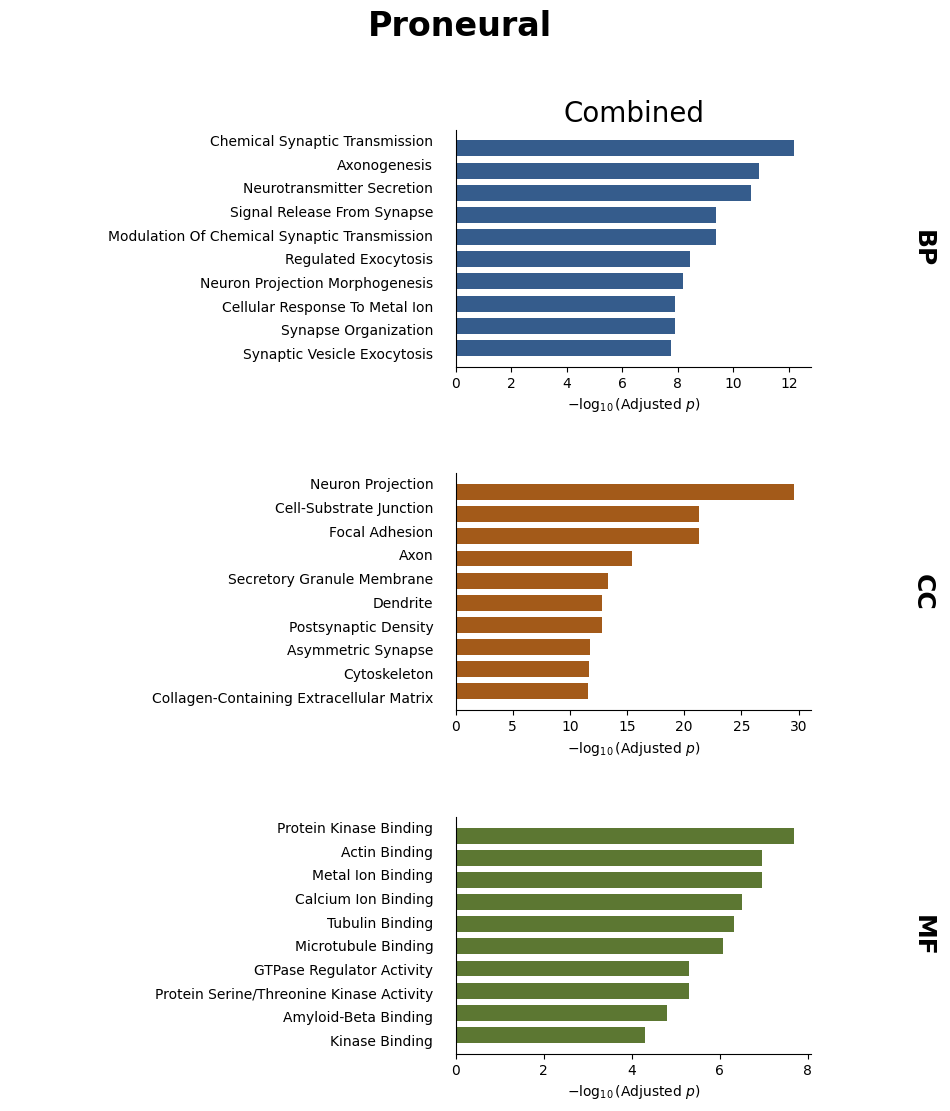

Classical: BP
Classical: CC
Classical: MF


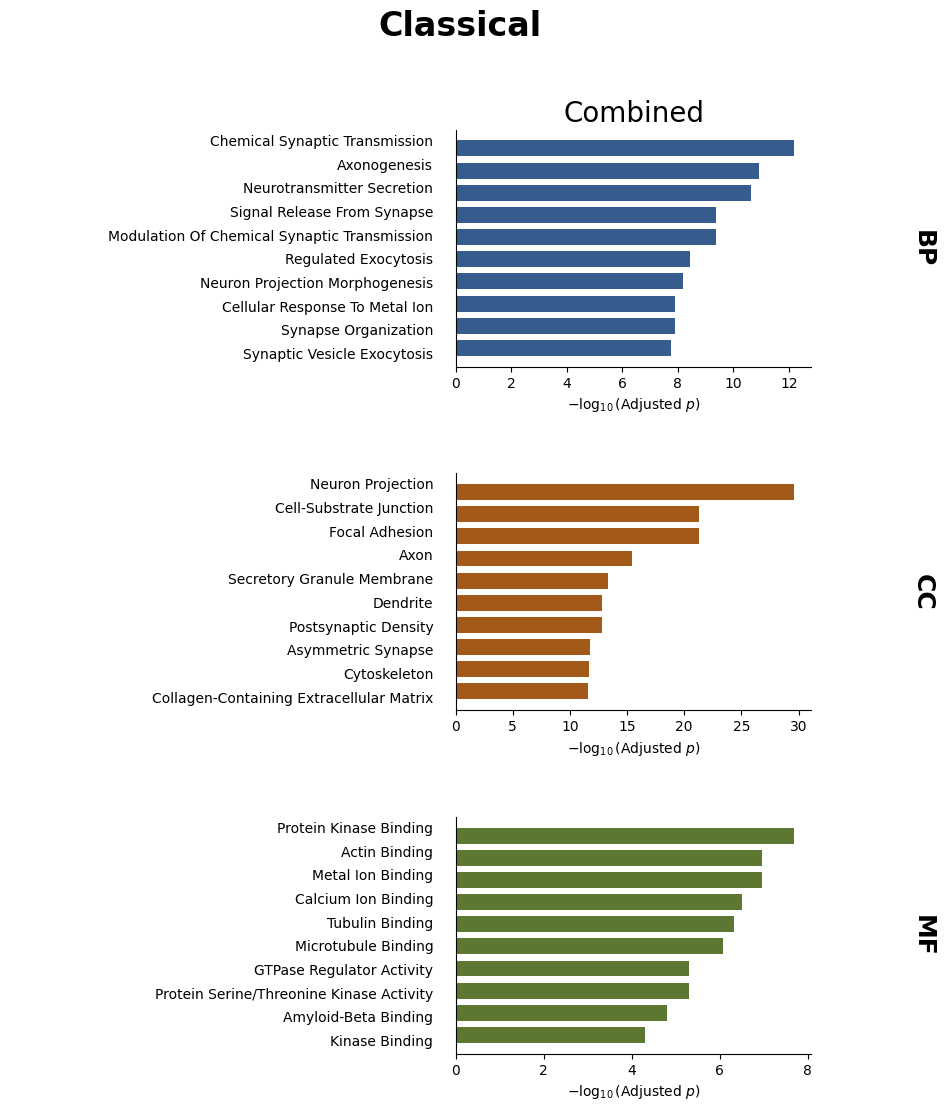

Mesenchymal: BP
Mesenchymal: CC
Mesenchymal: MF


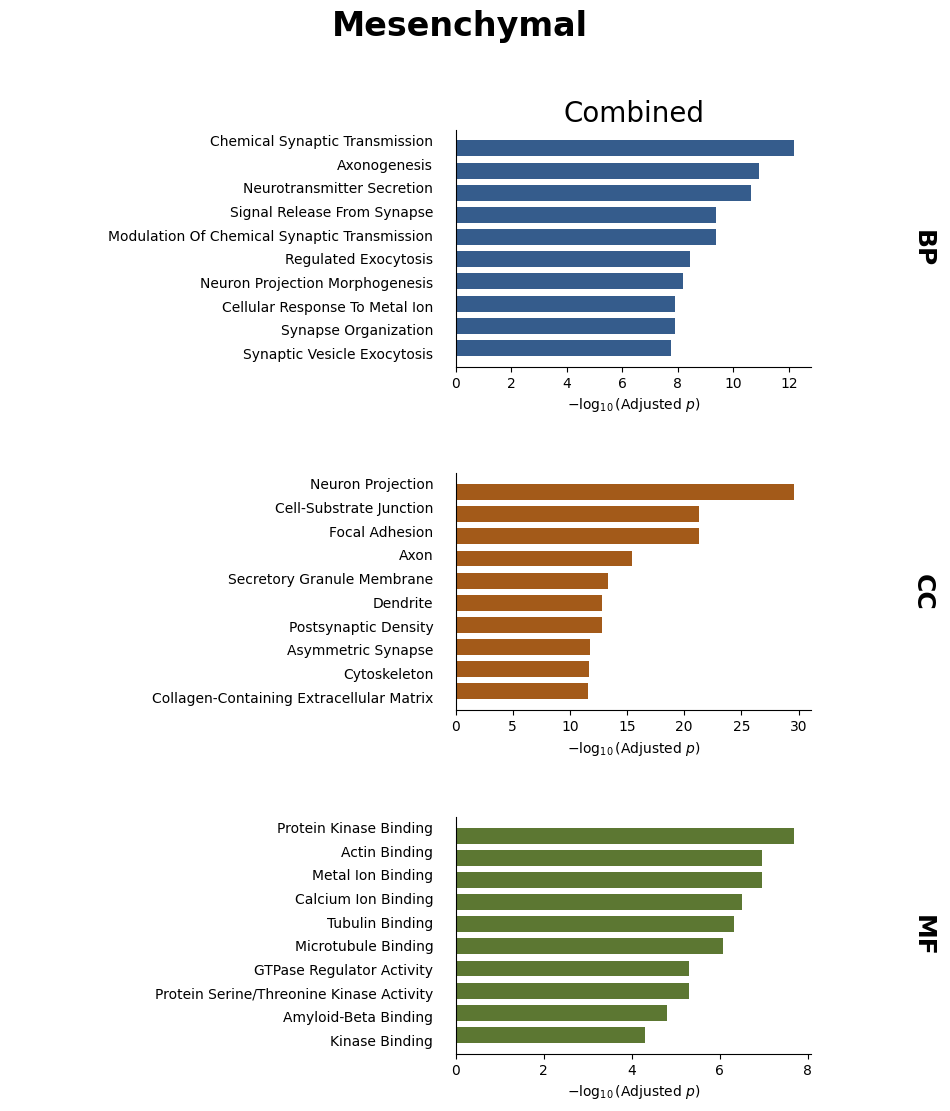

IDH: BP
IDH: CC
IDH: MF


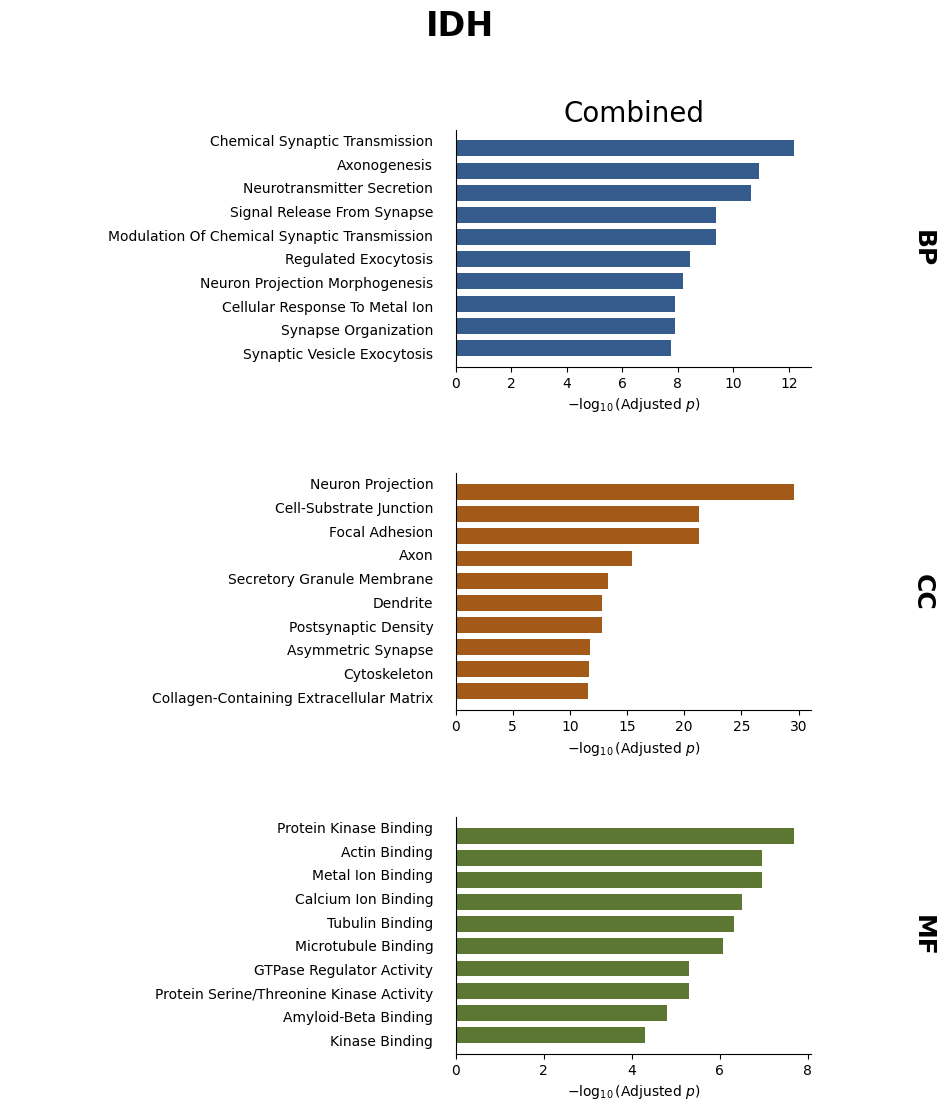

In [2]:
import pandas as pd
shared = []

for subtype, file in files.items():

    df = pd.read_csv(file)

    sig = df[
        (df["pvalue"] < 0.05) &
        (abs(df["log2FC"]) > 1)
    ]

    shared.append(
        set(sig["gene_name"].str.upper())
    )

shared_genes = set.intersection(*shared)

go_shared = {}

for subtype, file in files.items():

    go_shared[subtype] = ge.analyze_subtype(
        file,
        subtype,
        direction="combined",
        gene_filter=shared_genes
    )

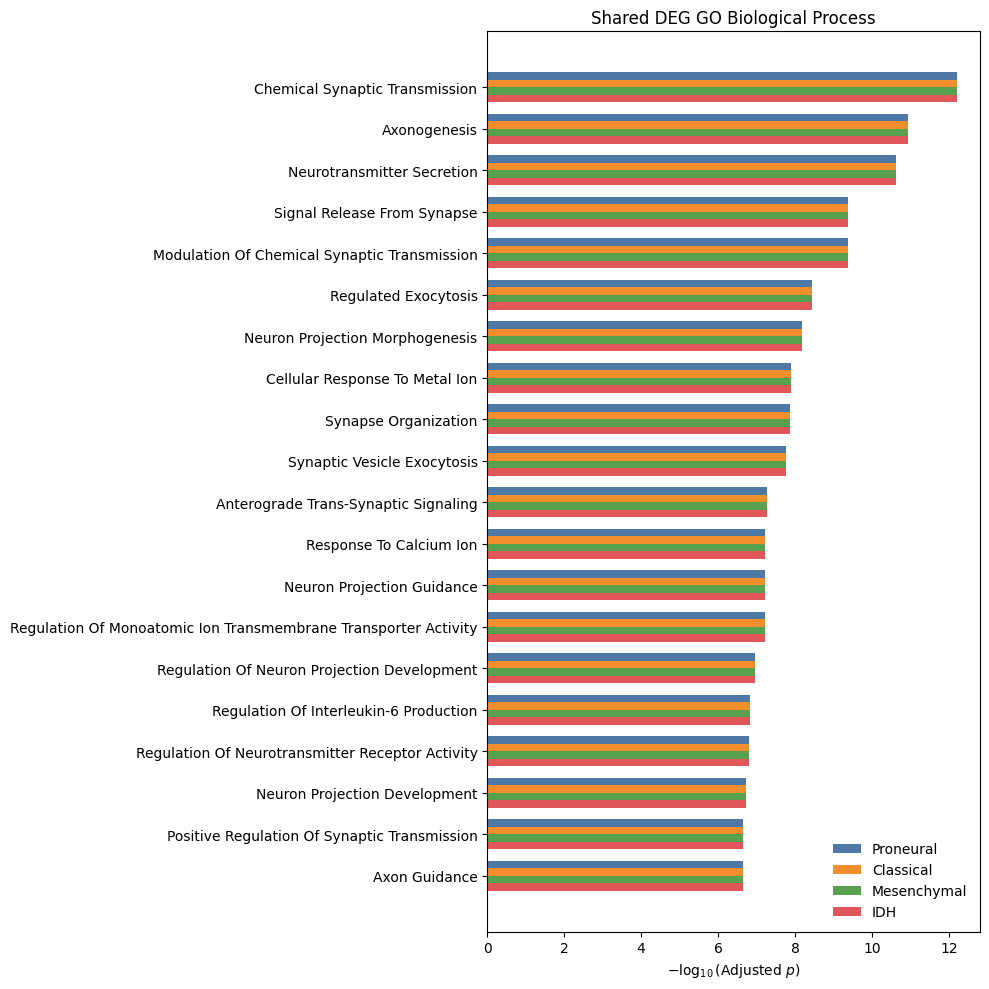

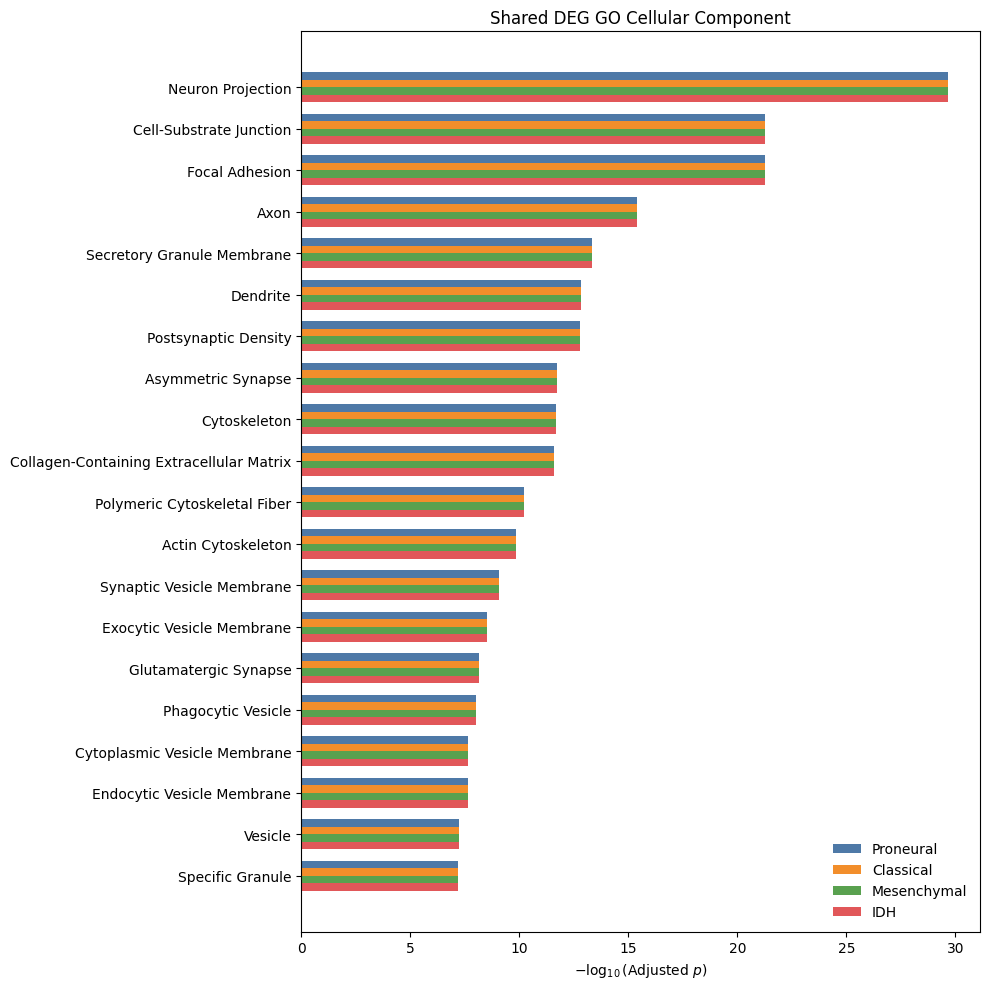

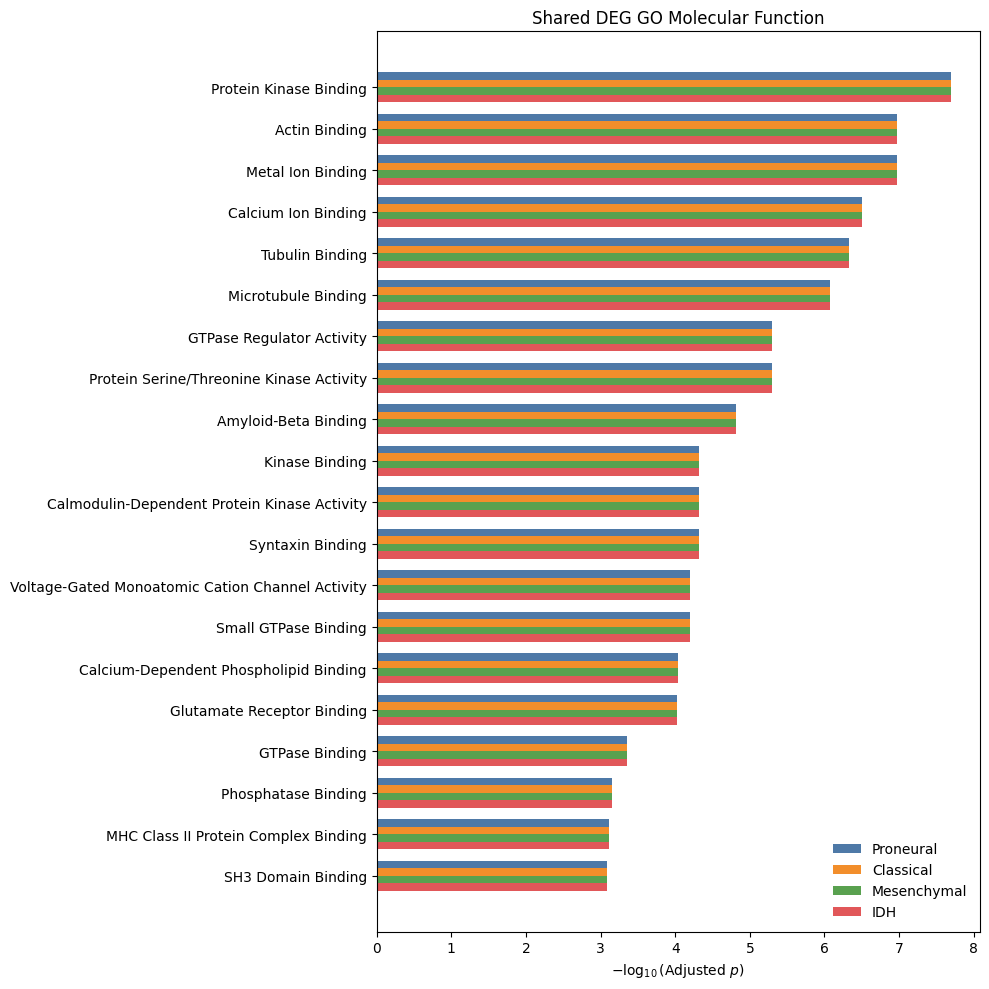

In [3]:
bp = ge.build_go_matrix(
    go_shared,
    ontology="BP",
    min_subtypes=4
)

ge.plot_go_comparison(
    bp,
    "Shared DEG GO Biological Process"
)

cc = ge.build_go_matrix(
    go_shared,
    ontology="CC",
    min_subtypes=4
)

ge.plot_go_comparison(
    cc,
    "Shared DEG GO Cellular Component"
)

mf = ge.build_go_matrix(
    go_shared,
    ontology="MF",
    min_subtypes=4
)

ge.plot_go_comparison(
    mf,
    "Shared DEG GO Molecular Function"
)

Proneural: BP UP
Proneural: BP DOWN
Proneural: CC UP
Proneural: CC DOWN
Proneural: MF UP
Proneural: MF DOWN


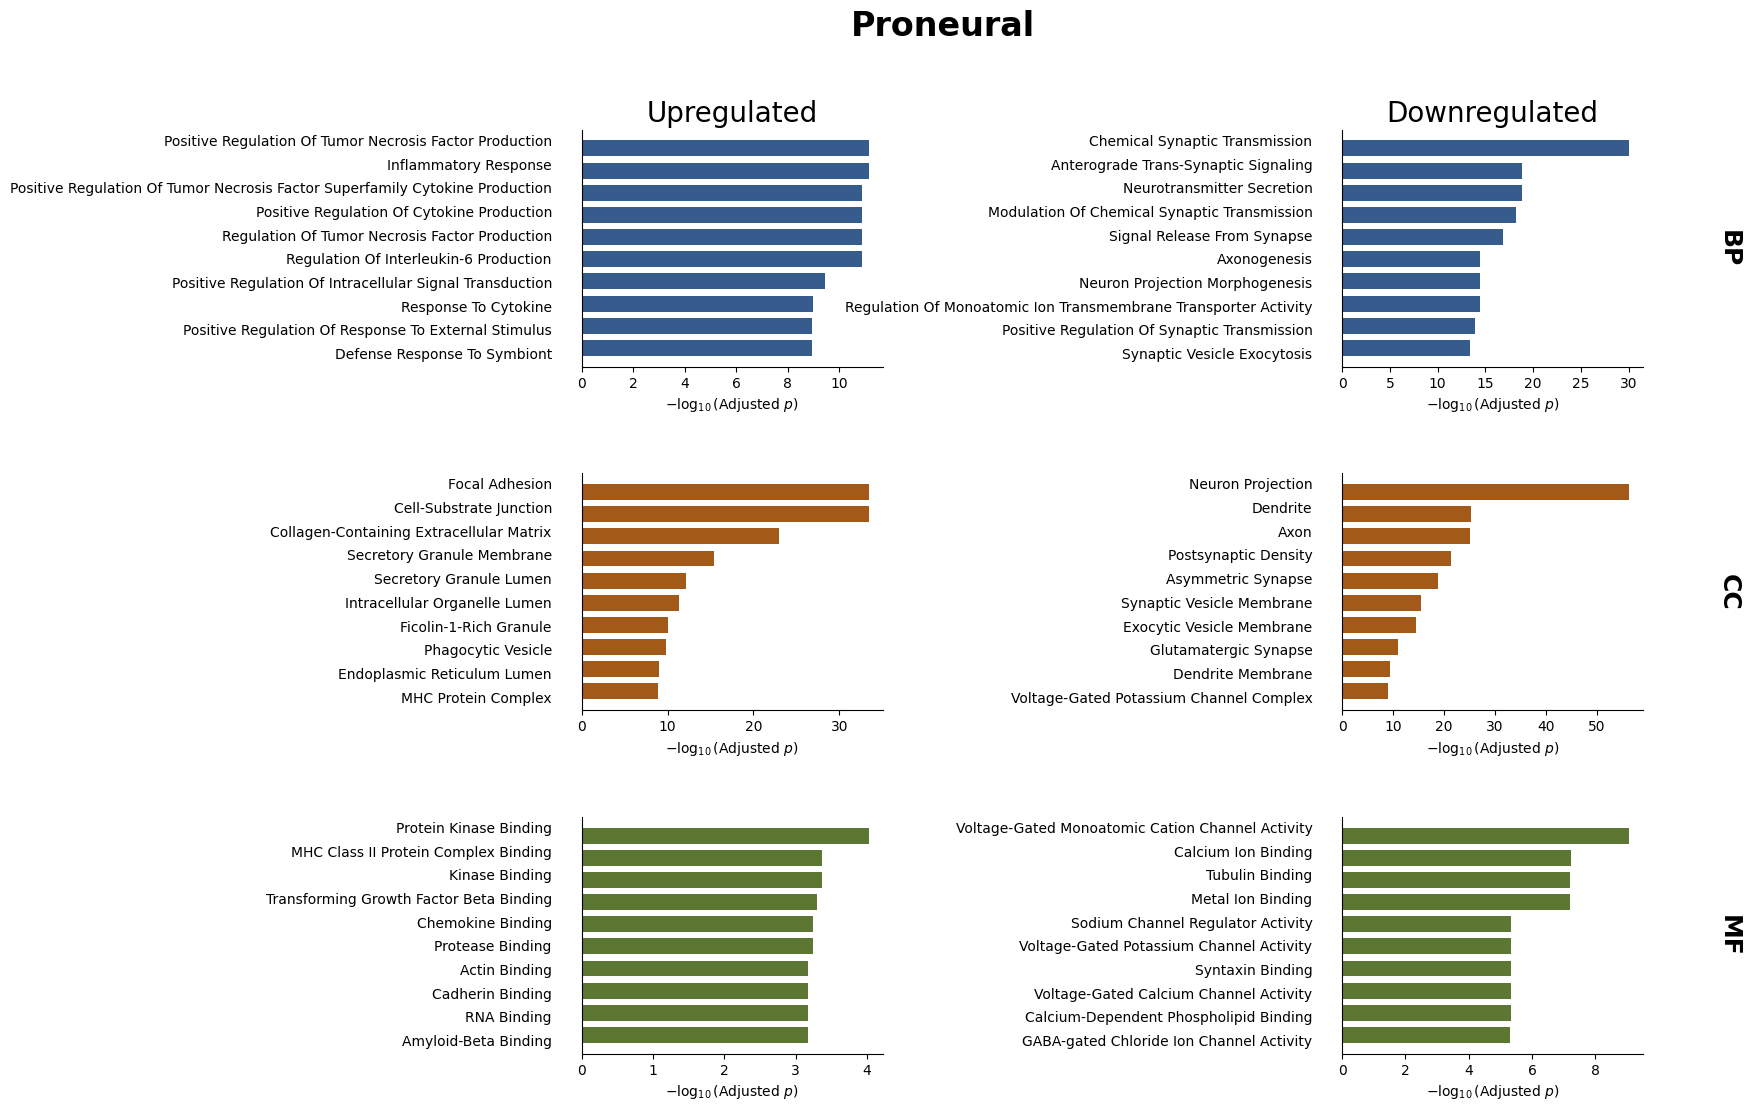

Classical: BP UP
Classical: BP DOWN
Classical: CC UP
Classical: CC DOWN
Classical: MF UP
Classical: MF DOWN


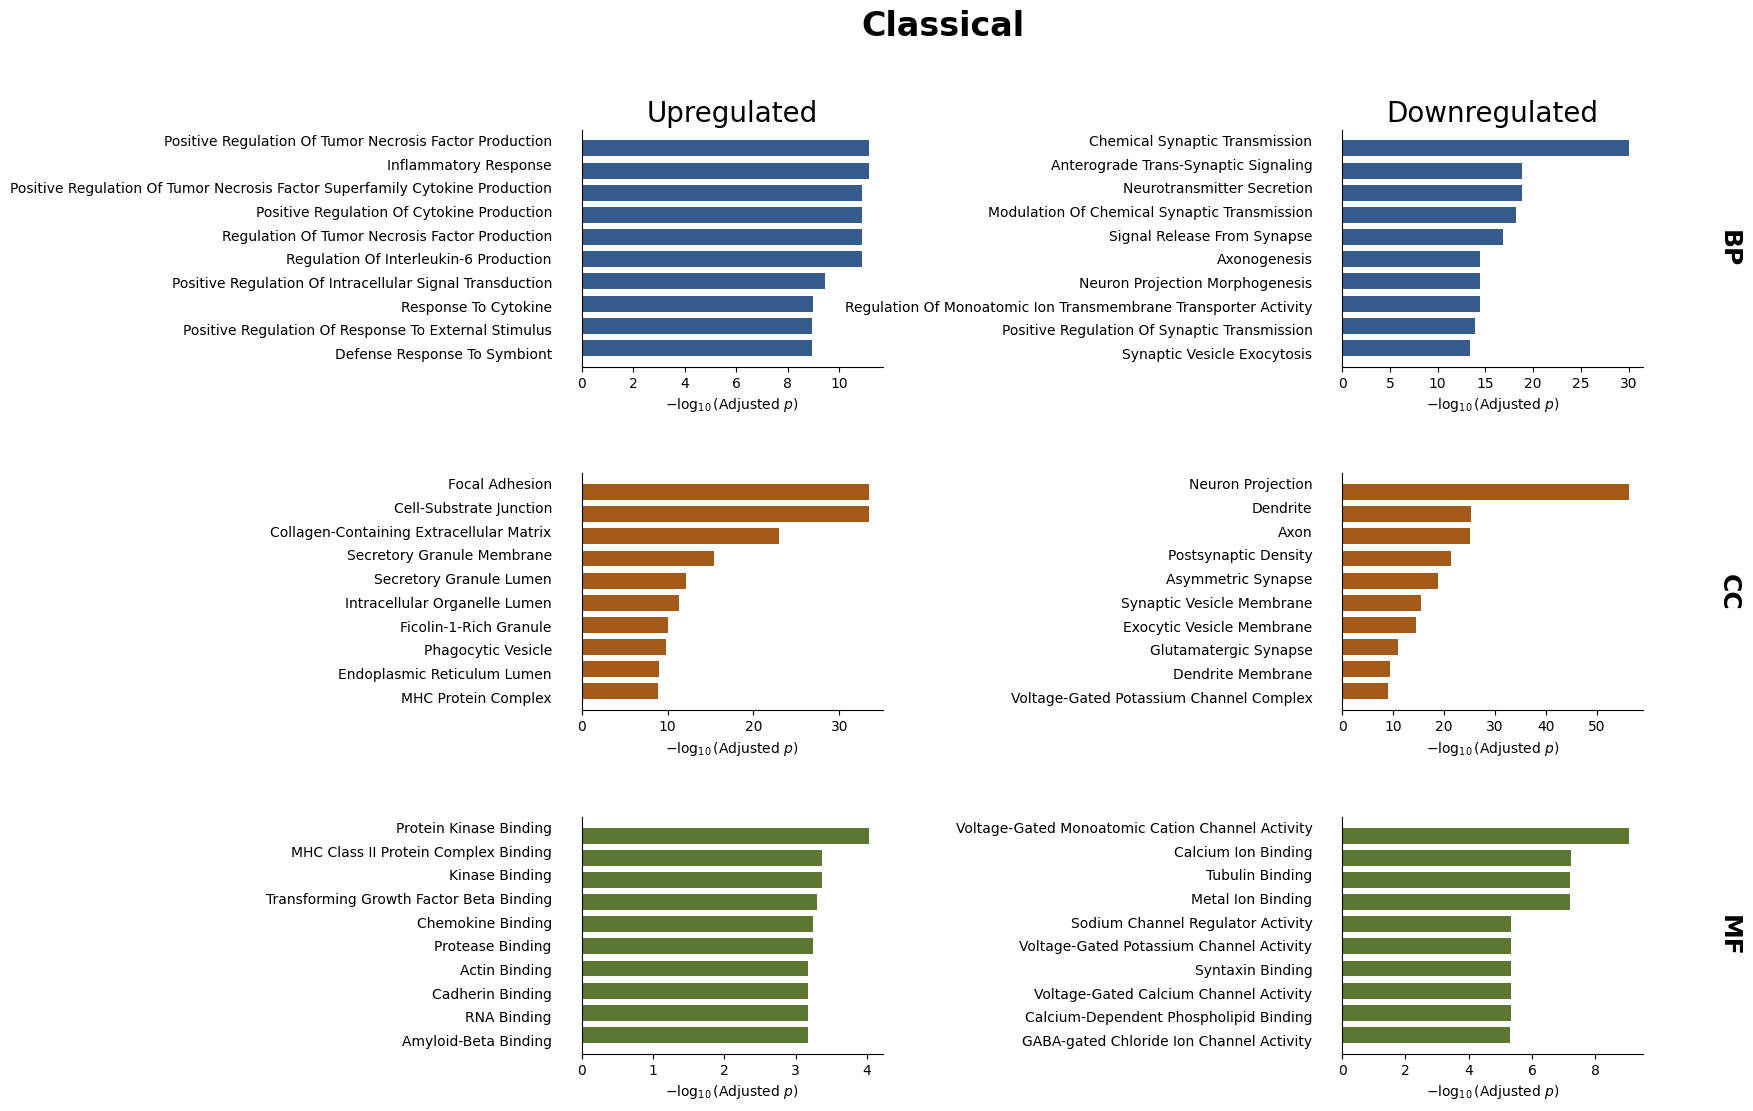

Mesenchymal: BP UP
Mesenchymal: BP DOWN
Mesenchymal: CC UP
Mesenchymal: CC DOWN
Mesenchymal: MF UP
Mesenchymal: MF DOWN


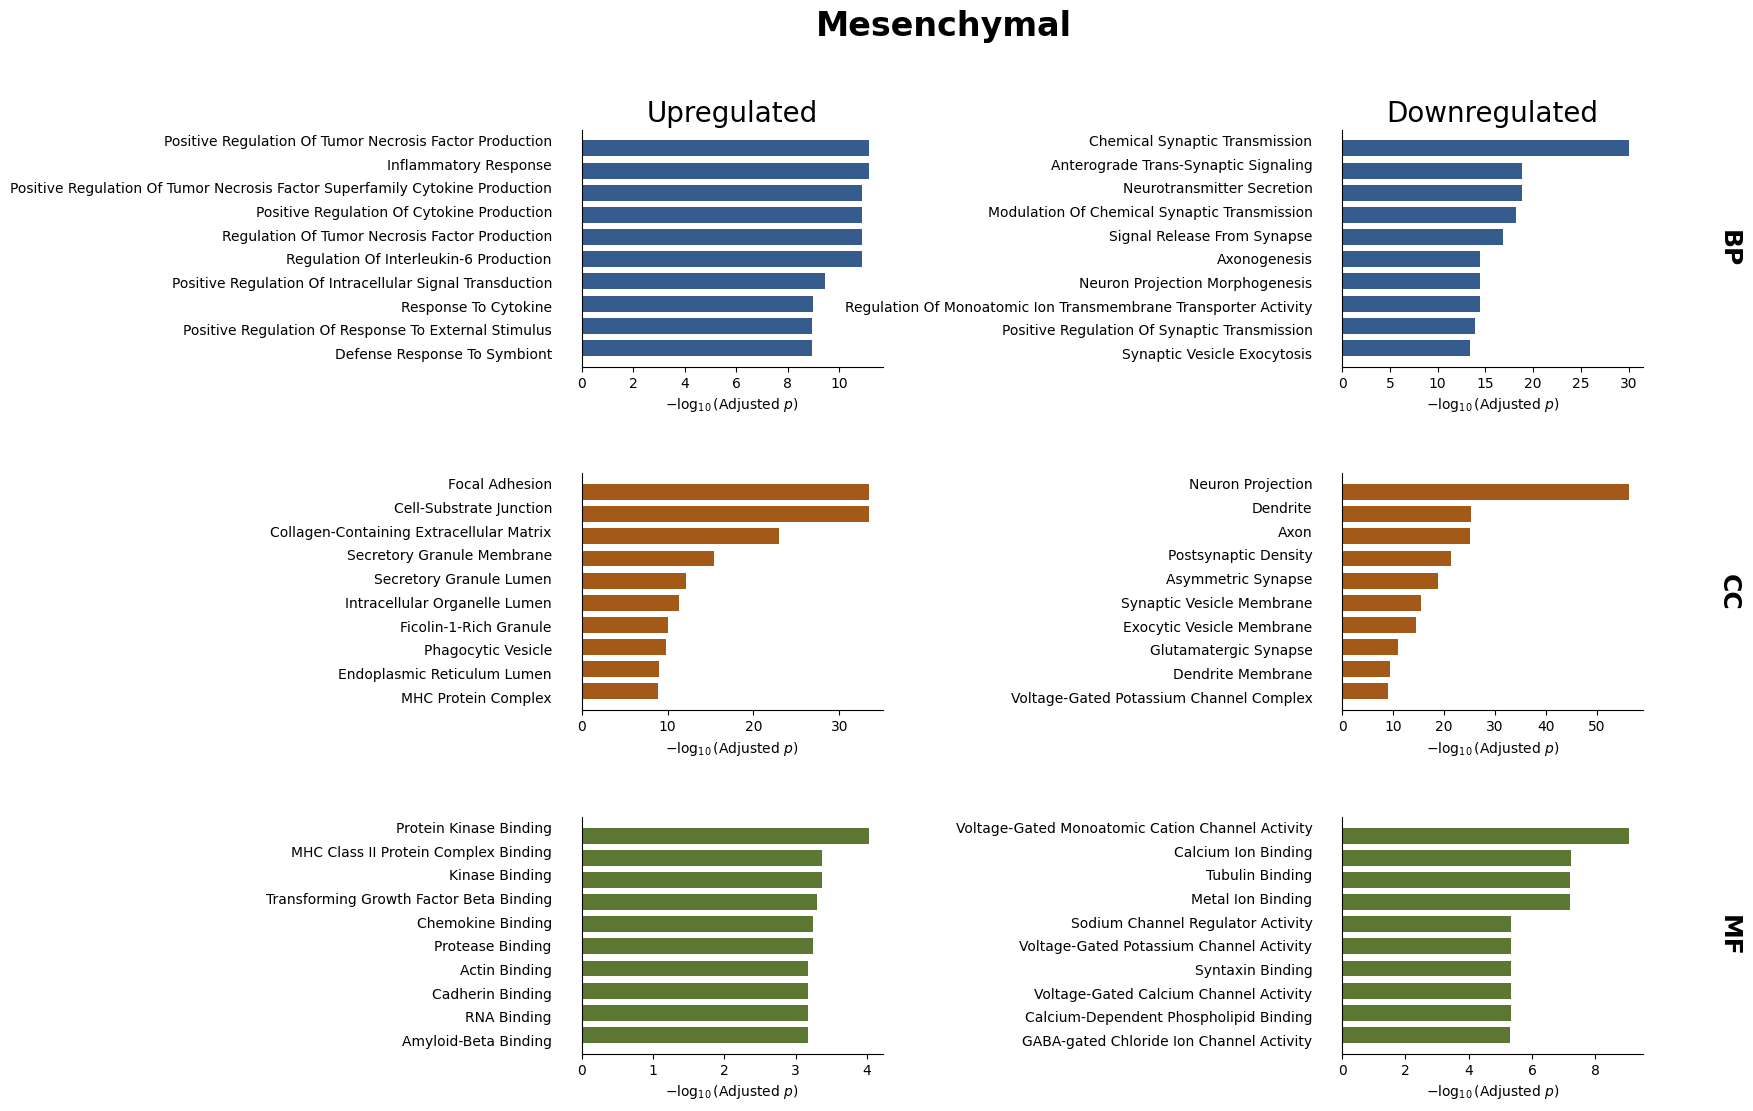

IDH: BP UP
IDH: BP DOWN
IDH: CC UP
IDH: CC DOWN
IDH: MF UP
IDH: MF DOWN


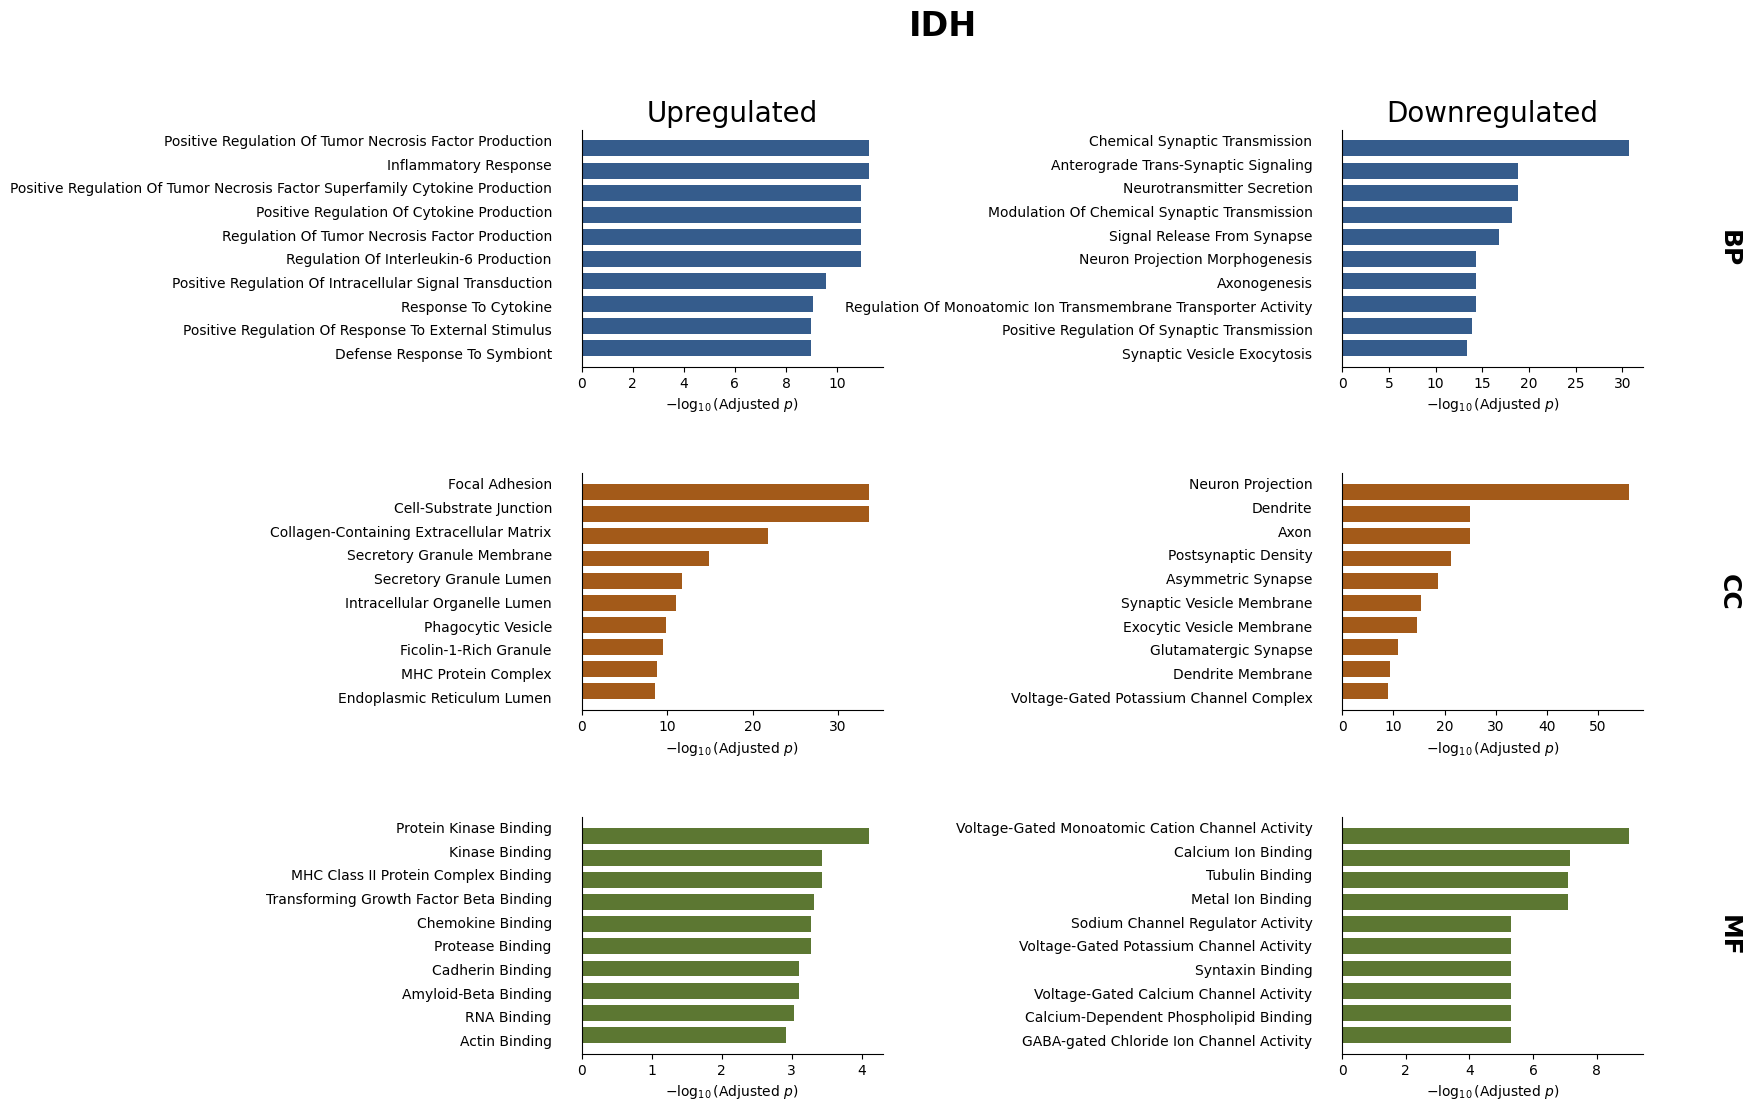

In [4]:
go_split = {}

for subtype, file in files.items():

    go_split[subtype] = ge.analyze_subtype(
        file,
        subtype,
        direction="split",
        gene_filter=shared_genes
    )